<a href="https://colab.research.google.com/github/Vivek-afk81/ml-workshop/blob/main/Audio_Models_Hugging_Face.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Audio Processing using Python

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa #standard library for dealing with audio

In [3]:
audio_path="/media/audio.mp3"

In [4]:
y,sr=librosa.load(audio_path, sr=None)

In [5]:
y

array([0.00026489, 0.00024976, 0.00016459, ..., 0.00112344, 0.00131525,
       0.00124063], dtype=float32)

In [6]:
y.shape

(293280,)

In [8]:
sr  #- Sampling rate (sr) = number of samples per second used to represent the audio waveform. For example, CD-quality audio uses 44,100 Hz (44.1 kHz), meaning 44,100 samples per second.

16000

###Visualizing

Text(0, 0.5, 'Amplitude')

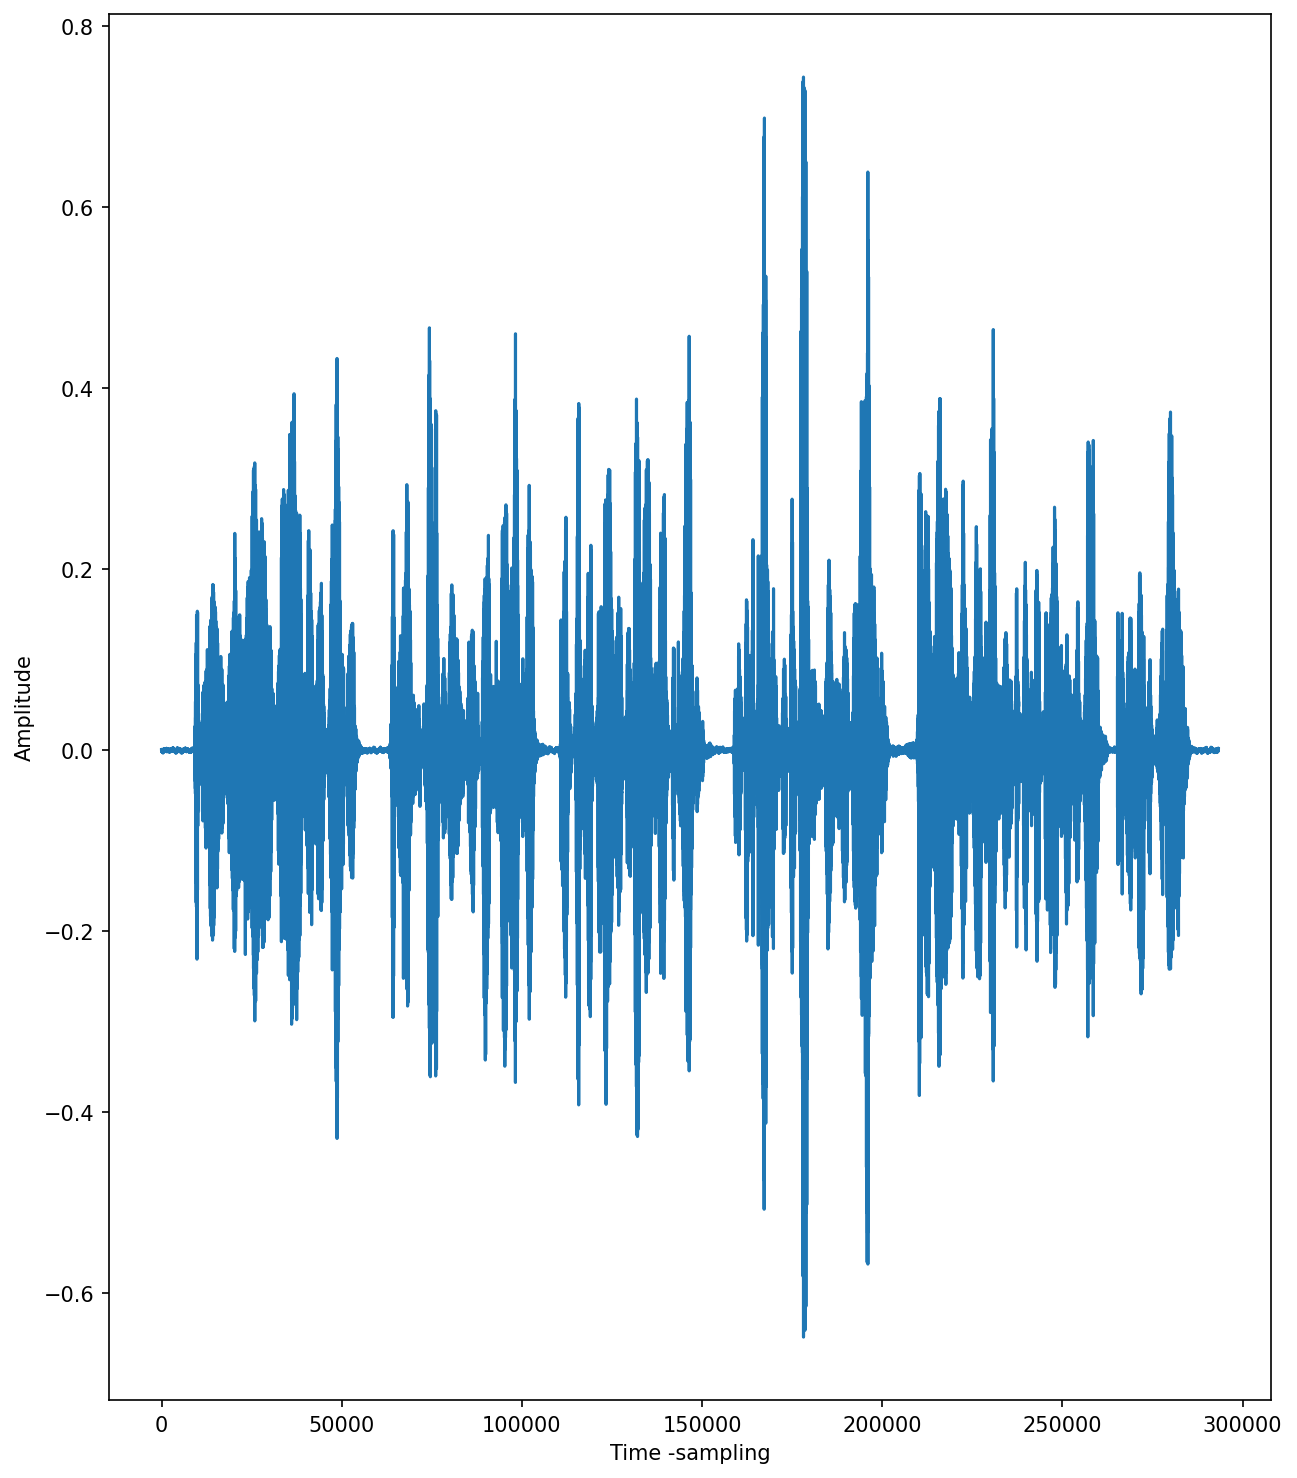

In [10]:
plt.figure(figsize=(10,12),dpi=150)
plt.plot(y)
plt.xlabel("Time -sampling")
plt.ylabel("Amplitude")

In [12]:
len(y)/sr #18.33 sec long audio

18.33

In [14]:
from IPython.display import Audio

In [15]:
Audio(data=y,rate=sr)

###DFT -Discrete Fourier Transform

fft.rfft(a, n=None, axis =- 1, norm=None, out=None)

Compute the one-dimensional discrete Fourier Transform for real input.

This function computes the one-dimensional n-point discrete Fourier Transform (DFT) of a
real-valued array by means of an efficient algorithm called the Fast Fourier Transform (FFT).

[source]

In [20]:
# Create a Hann window of the same length as the audio signal y
# A Hann window tapers the signal at the edges to reduce spectral leakage
window = np.hanning(len(y))

# Apply the window to the audio signal
# This multiplies each sample of y by the corresponding window value
# Result: the audio is smoothly faded in/out at the edges
windowed_input = y * window

# Compute the Discrete Fourier Transform (DFT) of the windowed signal
# np.fft.rfft computes the FFT for real-valued input and returns only the positive frequency terms
# Result: frequency-domain representation of the signal
dft = np.fft.rfft(windowed_input)

In [21]:
dft

array([-1.86261994e+01+0.00000000e+00j,  9.28135505e+00+1.32683733e-01j,
        1.58371706e-01-1.37403646e-02j, ...,
        5.96883425e-05+1.24873961e-04j, -4.06976410e-05-8.91529285e-05j,
        1.86791506e-05+0.00000000e+00j])

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Discrete Fourier Transform')

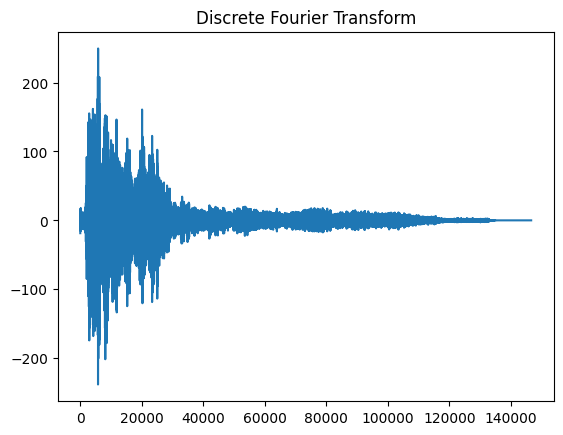

In [19]:
plt.plot(dft)
plt.title("Discrete Fourier Transform")

In [23]:
amplitude=np.abs(dft)

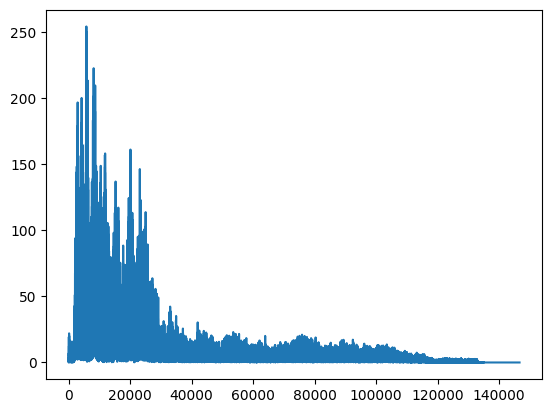

In [24]:
plt.plot(amplitude)

In [25]:
amplitude_db=librosa.amplitude_to_db(amplitude,ref=np.max)

In [26]:
frequency=librosa.fft_frequencies(sr=sr, n_fft=len(y))

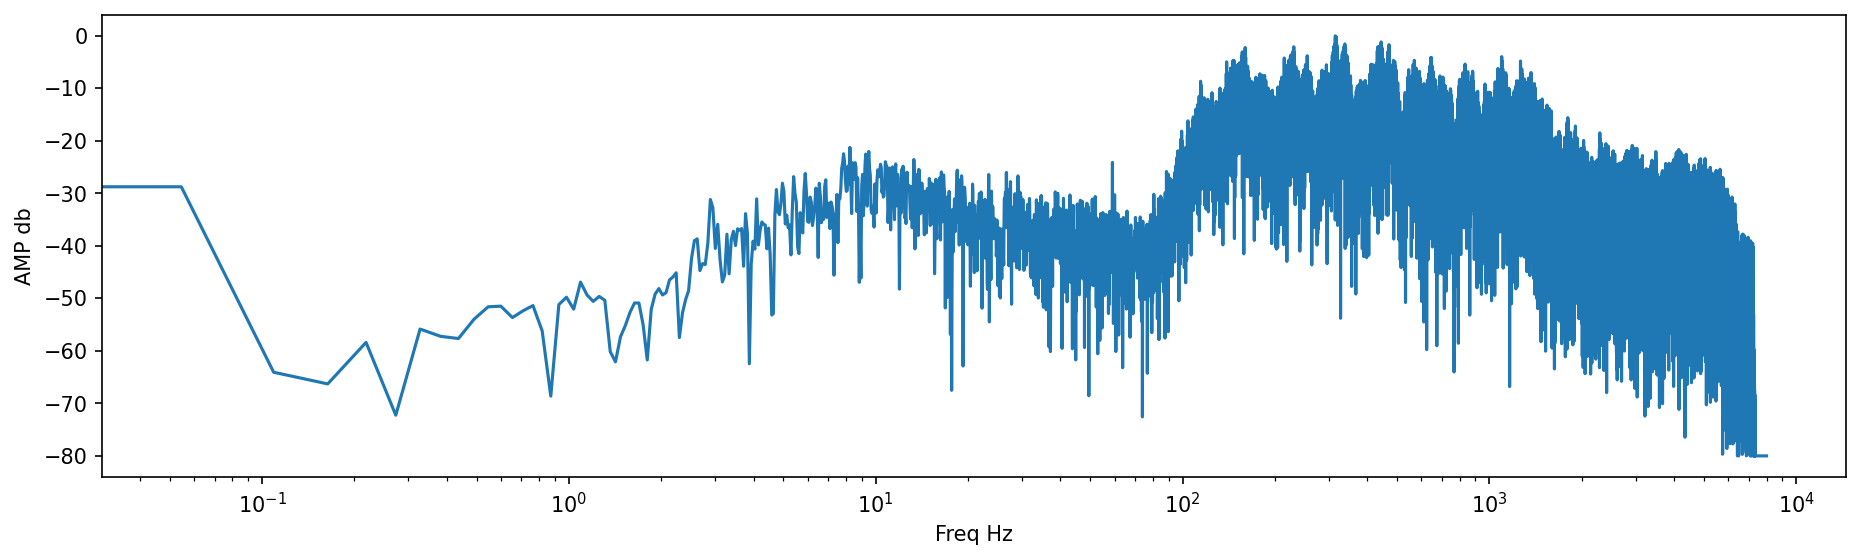

In [29]:
plt.figure(figsize=(15,4),dpi=150)
plt.plot(frequency,amplitude_db)
plt.xlabel("Freq Hz")
plt.ylabel("AMP db")
plt.xscale("log")